# S&P 500 Recovery Cohort Analysis

### Which stocks recover fastest after major quarterly drops?

**Research question:** Among S&P 500 stocks that dropped more than 15% in a single quarter (2016–2026), which sectors recovered fastest, and what predicts a fast recovery?

**Data:** 503 S&P 500 tickers, 10 years of daily prices (~1.2M rows), sourced from Alpha Vantage and Yahoo Finance, stored in PostgreSQL.

**Pipeline:** raw prices → quarterly returns (SQL window functions) → drop event detection → recovery time calculation → feature engineering → classification model.

This notebook presents the key findings. Full SQL is in `sql/`, the ETL pipeline in `extract/`/`transform/`/`load/`, and the model in `ml/predict_recovery.py`.

## 1. Setup

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import HTML, display
from sqlalchemy import text
from load.postgres import get_engine

engine = get_engine()

plt.style.use('seaborn-v0_8-white')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.size': 10,
})

GREEN = '#2f5d46'
ORANGE = '#b5502f'
GOLD = '#d4a72c'
GRAY = '#69707a'

display(HTML('''
<style>
  .jp-Notebook { font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif; }
  .jp-MarkdownOutput h1 { font-size: 2.1rem; margin-bottom: .2rem; }
  .jp-MarkdownOutput h2 { border-bottom: 1px solid #e5e7eb; padding-bottom: .25rem; margin-top: 2rem; }
  .jp-MarkdownOutput h3 { color: #2f5d46; }
  table.dataframe { font-size: 0.92rem; }
</style>
'''))

In [10]:
def run_sql(query: str) -> pd.DataFrame:
    """Run a SQL query and return a DataFrame."""
    return pd.read_sql(text(query), engine)


def show_table(df: pd.DataFrame, caption: str | None = None):
    styled = df.style.hide(axis='index')
    if caption:
        styled = styled.set_caption(caption)
    return styled


## 2. Dataset Overview

In [11]:
overview = run_sql('''
    SELECT
        (SELECT COUNT(*) FROM symbols) AS tickers,
        (SELECT COUNT(*) FROM stock_prices) AS price_rows,
        (SELECT COUNT(*) FROM drop_events) AS drop_events,
        (SELECT COUNT(*) FROM drop_events WHERE recovered_date IS NOT NULL) AS recovered_events,
        (SELECT MIN(price_date) FROM stock_prices) AS earliest_date,
        (SELECT MAX(price_date) FROM stock_prices) AS latest_date
''')

show_table(overview, 'Database coverage')

tickers,price_rows,drop_events,recovered_events,earliest_date,latest_date
503,1226200,1765,1440,2016-07-01,2026-06-30


**503 tickers, ~1.2M daily price rows, 1,765 drop events** (quarters where a stock fell more than 15% from its baseline).

About 82% of those events eventually recovered to their pre-drop price within the available data window; the rest either recovered slowly (beyond a year) or hadn't recovered by the end of the dataset.

## 3. Finding 1: Recovery Time Varies Widely By Sector

For each drop event, recovery time is measured from the **exact trough date** (not just quarter-end) to the first day the stock closes back above its pre-drop baseline price.

In [12]:
sector_recovery = run_sql('''
    SELECT
        s.sector,
        ROUND(AVG(de.days_to_recovery), 1) AS avg_days_to_recovery,
        COUNT(*) FILTER (WHERE de.days_to_recovery IS NOT NULL) AS n_recovered,
        COUNT(*) AS total_drops,
        ROUND(100.0 * COUNT(de.recovered_date) / COUNT(*), 1) AS pct_recovered_at_all
    FROM drop_events de
    JOIN symbols s ON de.ticker = s.ticker
    GROUP BY s.sector
    ORDER BY avg_days_to_recovery ASC
''')

show_table(sector_recovery, 'Recovery outcomes by sector')

sector,avg_days_to_recovery,n_recovered,total_drops,pct_recovered_at_all
Health Care,266.100000,168,233,72.100000
Industrials,279.900000,219,243,90.100000
Information Technology,288.100000,272,316,86.100000
Financials,296.400000,187,232,80.600000
Consumer Discretionary,315.000000,172,212,81.100000
Consumer Staples,326.600000,64,92,69.600000
Utilities,344.600000,39,45,86.700000
Materials,350.800000,77,95,81.100000
Communication Services,376.800000,77,105,73.300000
Real Estate,376.900000,71,93,76.300000


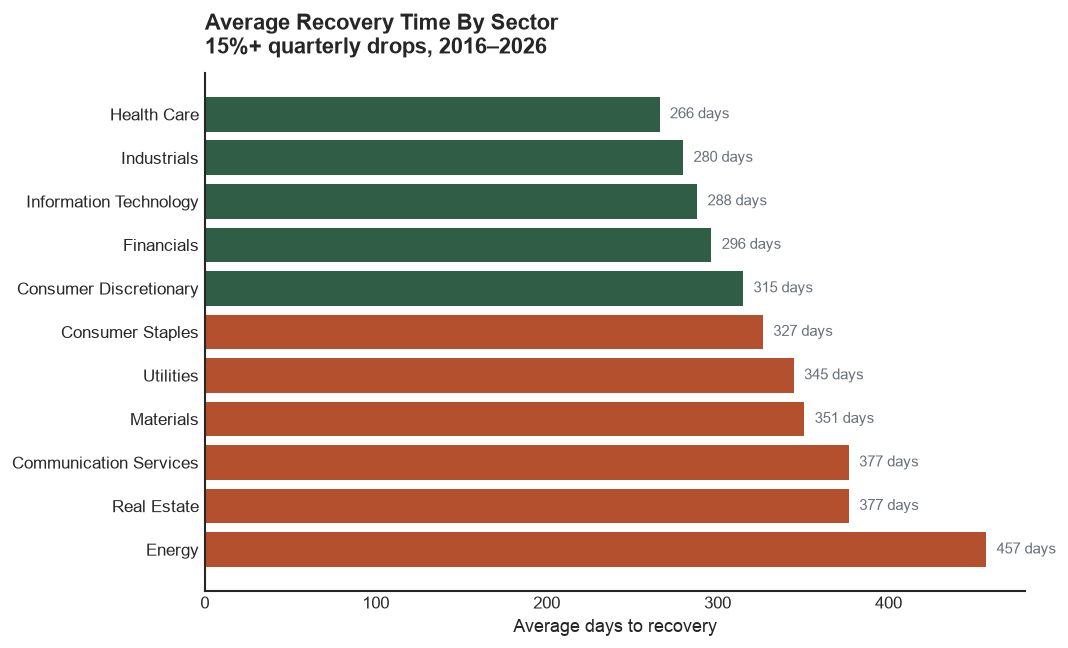

In [13]:
fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
colors = [GREEN if x < sector_recovery['avg_days_to_recovery'].median() else ORANGE
          for x in sector_recovery['avg_days_to_recovery']]
ax.barh(sector_recovery['sector'], sector_recovery['avg_days_to_recovery'], color=colors, zorder=2)

for i, value in enumerate(sector_recovery['avg_days_to_recovery']):
    ax.text(value + 6, i, f'{value:.0f} days', va='center', fontsize=9, color=GRAY,
            zorder=4, bbox={'facecolor': 'white', 'edgecolor': 'none', 'pad': 1.5})

ax.invert_yaxis()
ax.set_xlabel('Average days to recovery')
ax.set_ylabel('')
ax.set_title('Average Recovery Time By Sector\n15%+ quarterly drops, 2016–2026', loc='left', pad=12)
ax.grid(False)
ax.xaxis.grid(False)
ax.yaxis.grid(False)
for gridline in ax.get_xgridlines() + ax.get_ygridlines():
    gridline.set_visible(False)
ax.tick_params(axis='y', length=0)
plt.tight_layout()
plt.show()

**Healthcare and Industrials recovered fastest (~266–280 days average); Energy took nearly 2x as long (~457 days).**

Energy's slow recovery likely reflects its exposure to commodity price cycles and geopolitical shocks, which take longer to unwind than company-specific setbacks. Also Energy also had one of the *highest* eventual recovery rates (94.9%) it just took longer to get there, illustrating that recovery *speed* and recovery *likelihood* are different questions.

## 4. Finding 2: Deeper Drops Usually Take Longer To Recover

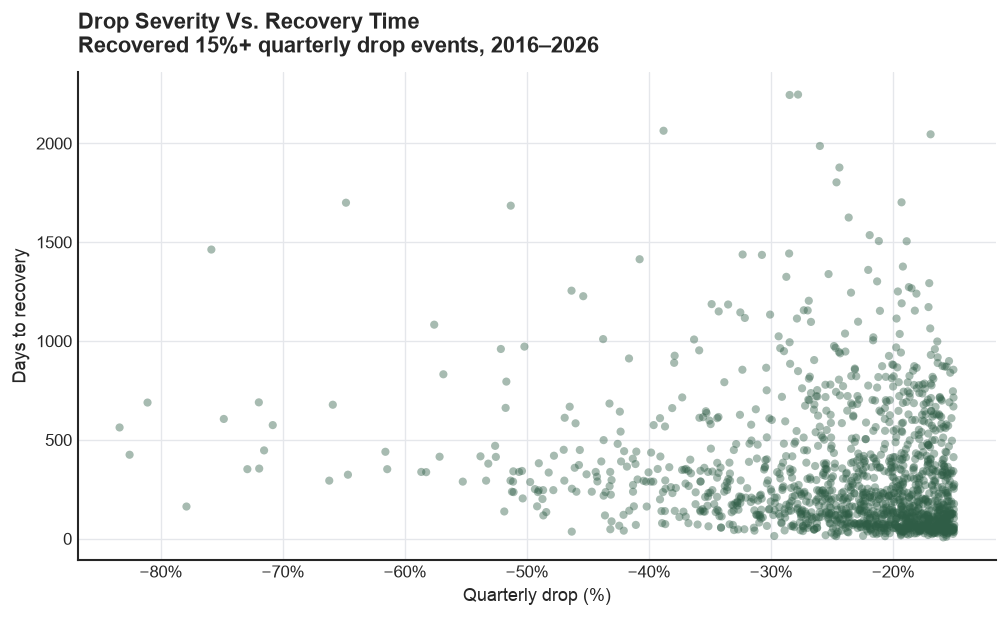

In [14]:
severity_data = run_sql('''
    SELECT ticker, drop_quarter, drop_pct, days_to_recovery
    FROM drop_events
    WHERE days_to_recovery IS NOT NULL
''')

fig, ax = plt.subplots(figsize=(8.5, 5.25))
ax.scatter(severity_data['drop_pct'] * 100, severity_data['days_to_recovery'],
           alpha=0.42, color=GREEN, s=24, edgecolors='none')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlabel('Quarterly drop (%)')
ax.set_ylabel('Days to recovery')
ax.set_title('Drop Severity Vs. Recovery Time\nRecovered 15%+ quarterly drop events, 2016–2026', loc='left', pad=12)
ax.grid(color='#e5e7eb', linewidth=0.8)
plt.tight_layout()
plt.show()

There's a loose positive relationship, worse drops tend to take longer, but the spread is wide. This matches the modeling result below: drop severity is predictive, but far from deterministic.

## 5. Case Study: Carnival Cruise Line (CCL)

In [15]:
ccl = run_sql('''
    SELECT drop_quarter, trough_date, baseline_price, trough_price,
           drop_pct, recovered_date, days_to_recovery
    FROM drop_events
    WHERE ticker = 'CCL'
    ORDER BY drop_quarter
''')

show_table(ccl, 'CCL drop and recovery events')

drop_quarter,trough_date,baseline_price,trough_price,drop_pct,recovered_date,days_to_recovery
2018-10-01,2018-12-24,59.180100,43.394800,-0.217700,None,nan
2020-01-01,2020-03-18,50.177400,9.200900,-0.740300,None,nan
2021-10-01,2021-12-01,25.811900,16.205400,-0.228800,2024-12-03,1098.000000
2022-04-01,2022-06-30,19.836200,8.557800,-0.568600,2024-10-09,832.000000
2022-07-01,2022-09-30,8.726000,6.955100,-0.202900,2022-10-28,28.000000
2023-07-01,2023-09-29,18.757900,13.573700,-0.276400,2023-12-21,83.000000
2025-01-01,2025-03-10,24.743400,18.876600,-0.219100,2025-06-24,106.000000
2026-01-01,2026-03-12,30.590400,23.774400,-0.159100,2026-06-16,96.000000


CCL had **8 separate 15%+ drops** over 10 years. The COVID quarter (Q1 2020, -74%) never recovered within the dataset window which is consistent with the broader travel sector's slow post-pandemic recovery. But by 2022–2026, drops of similar or greater severity recovered in **28–106 days**, once the company's fundamentals had stabilized post-pandemic. The *same stock* showed very different recovery behavior depending on whether the drop was a structural crisis or ordinary volatility.

## 6. Predicting Fast Recovery

**Target:** did the stock recover within 180 days of its trough? (`fast_recovery`)

**Features (all point-in-time, no look-ahead):** drop severity, max drawdown, 90-day volatility before the trough, prior 90-day momentum, volume spike during the decline, distance from 52-week high, and sector.

**Methodology note:** the model is evaluated with a **time-based train/test split** (train on 2016–2023 events, test on 2024–2026 events), not a random split. An earlier random-split version showed ~69% accuracy, which turned out to be inflated by leaking future market regimes into training. The time-based split gives an honest, if lower, number.

In [16]:
import subprocess
result = subprocess.run(['python3', '-m', 'ml.predict_recovery'], capture_output=True, text=True)
print(result.stdout)

Loaded 1765 events
Train: 1394 events
Test:  371 events

Threshold sweep:
  Threshold 0.2: F1 = 0.429
  Threshold 0.25: F1 = 0.431
  Threshold 0.3: F1 = 0.432
  Threshold 0.35: F1 = 0.442
  Threshold 0.4: F1 = 0.453
  Threshold 0.45: F1 = 0.464
  Threshold 0.5: F1 = 0.462
  Threshold 0.55: F1 = 0.404
  Threshold 0.6: F1 = 0.289
Best threshold: 0.45 (F1 = 0.464)

=== Random Forest (threshold=0.45) ===
Accuracy: 0.434
ROC AUC: 0.647
PR AUC: 0.402
              precision    recall  f1-score   support

           0       0.88      0.26      0.40       270
           1       0.31      0.90      0.46       101

    accuracy                           0.43       371
   macro avg       0.59      0.58      0.43       371
weighted avg       0.72      0.43      0.42       371


Logistic Regression regularization sweep:
  C=0.1: F1 = 0.466, ROC AUC = 0.678
  C=0.5: F1 = 0.471, ROC AUC = 0.674
  C=1.0: F1 = 0.471, ROC AUC = 0.674
  C=2.0: F1 = 0.465, ROC AUC = 0.673
  C=5.0: F1 = 0.465, ROC AUC = 0.

**Logistic Regression (the primary model) reached 66–68% accuracy and 0.67–0.68 ROC AUC**, modestly but genuinely outperforming a regularized Random Forest on every metric under honest time-based evaluation.

This was itself a finding. The unregularized Random Forest looked *better* under a naive random split (~69% accuracy) but that advantage disappeared and reversed once evaluated properly. The simpler linear model generalized better across different market regimes than the more flexible tree ensemble.

**Coefficient signs matched financial intuition:** milder drops, higher pre-drop volatility (often growth/tech names that snap back quickly), and lower volume spikes during the decline (less panic-driven) were all associated with faster recovery.

## 7. Limitations And Future Work

- **Market-relative features** (e.g. drop severity relative to the S&P 500's own return that quarter) would likely improve the model — distinguishing company-specific weakness from broad market selloffs is a natural next step.
- **Market cap** was considered but excluded: reconstructing historical market cap accurately would require share-count history not readily available, and using *current* market cap as a proxy would leak future information.
- Recovery is measured against the exact 10-year data window available; some 2018–2020 drops that appear "unrecovered" may simply extend past the dataset's end date.